In [1]:
import pandas as pd
import numpy as np

In [2]:
# In logistic regression basically we are classifying the labels into classes

In [1]:
# First lets see what exactly dot product does to the points and how that can be used in our problem

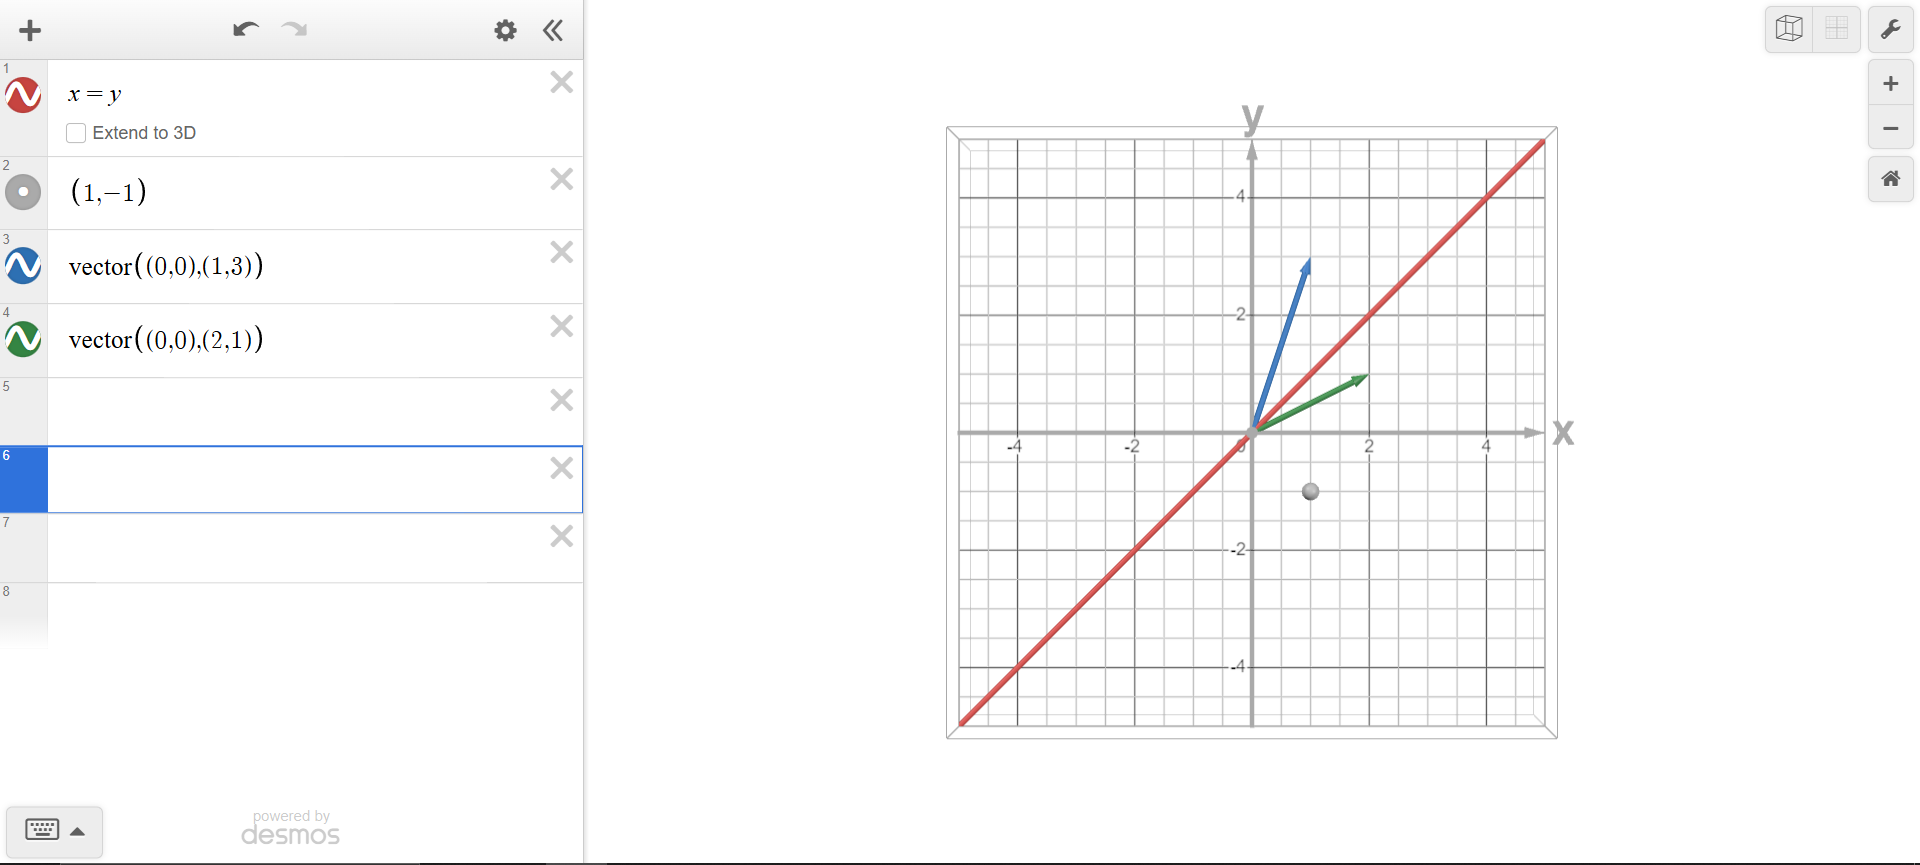

In [ ]:
# The closest point is 2,1 and is also positive as it will have angle < 90 if we calculate the dot product .
# The other point 1,3 is having an angle > 90 and will be treated as negative with respect to hyperplane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
np.random.seed(0)

class0 = np.random.randn(50,2) + np.array([-2,-2])
class1 = np.random.randn(50,2) + np.array([2,2])

X = np.vstack([class0, class1])

y = np.hstack([
    np.zeros(50),
    np.ones(50)
])

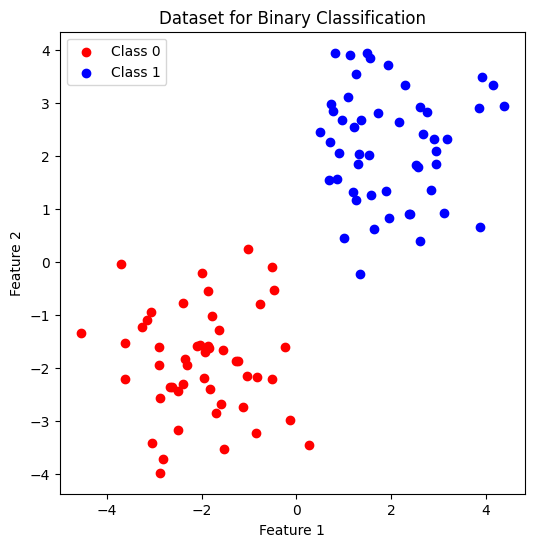

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(class0[:,0], class0[:,1], color='red', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], color='blue', label='Class 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset for Binary Classification")

plt.legend()
plt.show()

In [4]:
print("Shape of X:", X.shape)
print("First 5 samples:\n", X[:5])
print("Labels:\n", y[:10])

Shape of X: (100, 2)
First 5 samples:
 [[-0.23594765 -1.59984279]
 [-1.02126202  0.2408932 ]
 [-0.13244201 -2.97727788]
 [-1.04991158 -2.15135721]
 [-2.10321885 -1.5894015 ]]
Labels:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [5]:
# Suppose we use Linear Regression for this problem which is wrong

In [6]:
w = np.array([0.5, -0.5])
b = 0.0

# Decision Boundary Line Equation

This line represents the **decision boundary** of a logistic regression model. It's the threshold that separates predicted classes in a 2D feature space.

## Breaking Down the Formula

The equation transforms the model's decision rule into a line you can plot. In logistic regression, the model makes predictions based on whether $w_0 x_0 + w_1 x_1 + b$ is positive or negative. Setting this expression equal to zero gives you the boundary:

$$w_0 x + w_1 y + b = 0$$

Solving for $y$ (represented as `y_vals`) gives the line equation shown in your code.

## What Each Component Means

- **$-(w_0/w_1)$**: The slope of the decision boundary. It's derived from the ratio of the first two weight parameters. The negative sign comes from rearranging the equation to isolate $y$.
- **$x_{vals}$**: Your input feature values (the x-coordinates where you want to evaluate the line).
- **$-b/w_1$**: The y-intercept, determined by the bias term `b` and the second weight `w[1]`.

## Practical Significance

When you plot this line on your data, points on one side are predicted as class 0, and points on the other side as class 1. This linear boundary is what the logistic regression model learned during training—it's the optimal line (in a probabilistic sense) that separates your two classes.

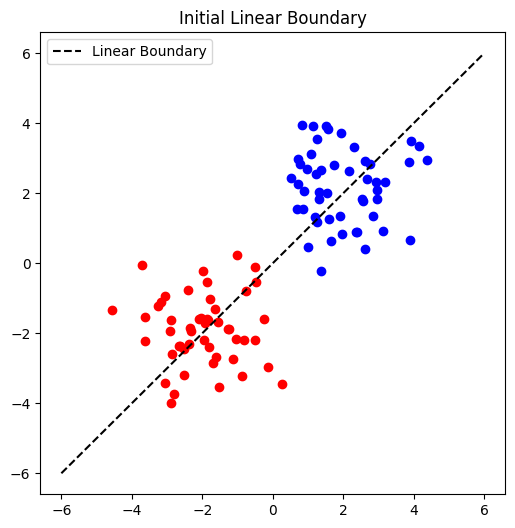

In [ ]:
x_vals = np.linspace(-6,6,100)
y_vals = -(w[0]/w[1]) * x_vals - b/w[1] 

plt.figure(figsize=(6,6))

plt.scatter(class0[:,0], class0[:,1], color='red')
plt.scatter(class1[:,0], class1[:,1], color='blue')

plt.plot(x_vals, y_vals, 'k--', label="Linear Boundary")

plt.title("Initial Linear Boundary")
plt.legend()

plt.show()

In [8]:
z = X @ w + b

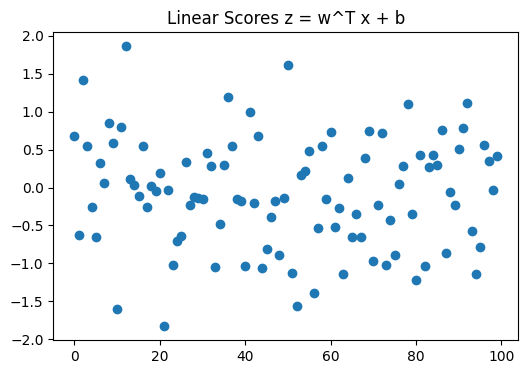

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(range(len(z)), z)
plt.title("Linear Scores z = w^T x + b")
plt.show()

In [ ]:
# Introducing the sigmoid function

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

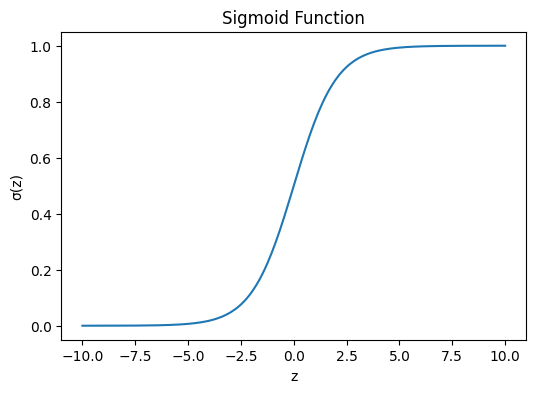

In [11]:
z_vals = np.linspace(-10,10,200)
s_vals = sigmoid(z_vals)

plt.figure(figsize=(6,4))

plt.plot(z_vals, s_vals)

plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")

plt.show()

In [ ]:
# We can use this to classify the points but how ? .. .

In [12]:
probs = sigmoid(z)

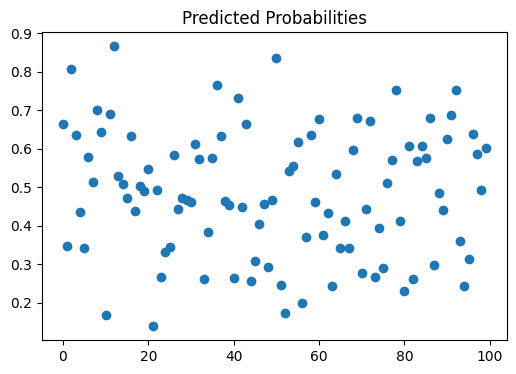

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(range(len(probs)), probs)
plt.title("Predicted Probabilities")
plt.show()

In [14]:
x_range = np.linspace(-6,6,50)
y_range = np.linspace(-6,6,50)

xx, yy = np.meshgrid(x_range, y_range)

grid = np.c_[xx.ravel(), yy.ravel()]

z_grid = sigmoid(grid @ w + b)
z_grid = z_grid.reshape(xx.shape)

In [15]:
fig = go.Figure(
    data=go.Surface(
        x=xx,
        y=yy,
        z=z_grid
    )
)

fig.update_layout(
    title="Probability Surface",
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="P(y=1)"
    )
)

fig.show()

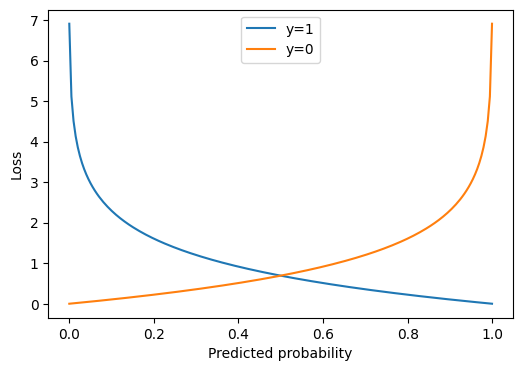

In [16]:
p = np.linspace(0.001,0.999,200)

loss_y1 = -np.log(p)
loss_y0 = -np.log(1-p)

plt.figure(figsize=(6,4))

plt.plot(p, loss_y1, label="y=1")
plt.plot(p, loss_y0, label="y=0")

plt.xlabel("Predicted probability")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [17]:
lr = 0.01

for epoch in range(100):

    z = X @ w + b
    p = sigmoid(z)

    grad_w = X.T @ (p - y) / len(y)
    grad_b = np.mean(p - y)

    w -= lr * grad_w
    b -= lr * grad_b

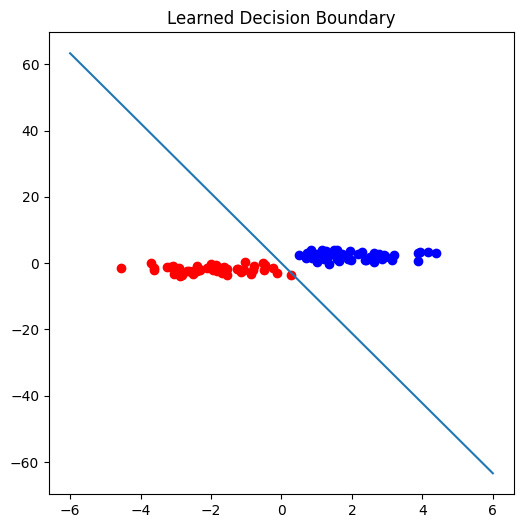

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(class0[:,0], class0[:,1], color='red')
plt.scatter(class1[:,0], class1[:,1], color='blue')

x_vals = np.linspace(-6,6,100)
y_vals = -(w[0]/w[1])*x_vals - b/w[1]

plt.plot(x_vals, y_vals)

plt.title("Learned Decision Boundary")

plt.show()